# Interface S-Matrix for a Rib Waveguide Step — Conjugated Inner Product

This notebook derives the interface scattering matrix for a step discontinuity
between two rib waveguides, starting from Maxwell's equations.
We use the **conjugated** asymmetric Poynting inner product $\frac{1}{2}\int (\mathbf{E}_a^* \times \mathbf{H}_b)\cdot\hat{z}\,dA$,
which is the physically natural **power** inner product.
We derive the interface formulas, discuss when a metric correction is needed,
and validate against a reference.

## 1. Mode Expansion and Boundary Conditions

In a $z$-invariant waveguide, the transverse electromagnetic fields are expanded in eigenmodes:

$$\mathbf{E}_t(x,y,z) = \sum_p \bigl[\, a_p^{+}\, e^{-j\beta_p z} \;+\; a_p^{-}\, e^{+j\beta_p z}\bigr]\, \mathbf{e}_p(x,y)$$

$$\mathbf{H}_t(x,y,z) = \sum_p \bigl[\, a_p^{+}\, e^{-j\beta_p z} \;-\; a_p^{-}\, e^{+j\beta_p z}\bigr]\, \mathbf{h}_p(x,y)$$

The **sign flip** on $\mathbf{H}_t$ for backward-propagating modes comes from Maxwell's curl equation: a mode traveling in $-z$ has $\mathbf{H}_t \to -\mathbf{H}_t$ relative to $\mathbf{E}_t$.

At an interface ($z = 0$) between medium L (left) and medium R (right), tangential field continuity demands:

$$\sum_p (a_p^{+} + a_p^{-})\,\mathbf{e}_p^L \;=\; \sum_q (b_q^{+} + b_q^{-})\,\mathbf{e}_q^R \qquad \text{(E continuity)}$$

$$\sum_p (a_p^{+} - a_p^{-})\,\mathbf{h}_p^L \;=\; \sum_q (b_q^{+} - b_q^{-})\,\mathbf{h}_q^R \qquad \text{(H continuity)}$$

where $a^+, a^-$ are forward/backward amplitudes in medium L and $b^+, b^-$ in medium R.

## 2. The Conjugated Asymmetric Inner Product

To convert the vector continuity equations into a matrix system, we project them
onto test functions. We use the **conjugated asymmetric Poynting overlap**:

$$\langle \mathbf{e}_a,\, \mathbf{h}_b \rangle \;=\; \frac{1}{2}\int_S (\mathbf{e}_a^* \times \mathbf{h}_b)\cdot\hat{z}\; dA$$

The conjugation acts on the **first** argument (the E-field). This is the natural
**power** inner product: $\langle \mathbf{e}_a, \mathbf{h}_a \rangle = \frac{1}{2}\int (\mathbf{e}_a^* \times \mathbf{h}_a)\cdot\hat{z}\,dA = P_a$
gives the time-averaged power carried by mode $a$.

This product is **sesquilinear**: linear in the second argument, antilinear in the first.
It is **not** symmetric: $\langle \mathbf{e}_a, \mathbf{h}_b \rangle \neq \langle \mathbf{e}_b, \mathbf{h}_a \rangle$ in general.

Define the overlap and metric matrices:

| Matrix | Definition | Meaning |
|--------|-----------|--------|
| $O_{LR}[i,j]$ | $\langle \mathbf{e}_i^L,\, \mathbf{h}_j^R \rangle$ | cross-overlap, left E$^*$ with right H |
| $O_{RL}[i,j]$ | $\langle \mathbf{e}_i^R,\, \mathbf{h}_j^L \rangle$ | cross-overlap, right E$^*$ with left H |
| $G_{LL}[i,j]$ | $\langle \mathbf{e}_i^L,\, \mathbf{h}_j^L \rangle$ | self-overlap (metric) for left modes |
| $G_{RR}[i,j]$ | $\langle \mathbf{e}_i^R,\, \mathbf{h}_j^R \rangle$ | self-overlap (metric) for right modes |

**Key properties** (for lossless waveguides, conjugated product):

- **Conjugated orthogonality**: For lossless media ($\varepsilon, \mu$ real), the divergence identity $\nabla\cdot(\mathbf{E}_a^* \times \mathbf{H}_b + \mathbf{E}_b \times \mathbf{H}_a^*) = 0$ integrates to $(\beta_a - \beta_b)\int(\mathbf{e}_a^* \times \mathbf{h}_b + \mathbf{e}_b \times \mathbf{h}_a^*)\cdot\hat{z}\,dA = 0$. For modes with $\beta_a \neq \beta_b$, this gives $\langle \mathbf{e}_a, \mathbf{h}_b\rangle = 0$ (orthogonality).

- **Hermitian metric**: $G_{LL} = G_{LL}^\dagger$ and $G_{RR} = G_{RR}^\dagger$. For eigenmodes (which are orthogonal), $G_{LL}$ is diagonal with real positive entries $G_{LL}[i,i] = P_i$ (power carried by mode $i$).

- **No cross-waveguide reciprocity**: $O_{LR} \neq O_{RL}^\dagger$ in general (different waveguide geometries break the relation).

For **orthonormalized** modes: $G_{LL} = G_{RR} = I$.

### Why not the symmetric product?

The *symmetric conjugated* inner product would be:

$$\langle \mathbf{e}_a,\, \mathbf{h}_b \rangle_{\text{sym}} = \frac{1}{4}\int_S \bigl[(\mathbf{e}_a^* \times \mathbf{h}_b) + (\mathbf{e}_b \times \mathbf{h}_a^*)\bigr]\cdot\hat{z}\; dA$$

Note: with conjugation, this satisfies $\langle \mathbf{e}_a, \mathbf{h}_b \rangle_{\text{sym}} = \langle \mathbf{e}_b, \mathbf{h}_a \rangle_{\text{sym}}^*$
(Hermitian symmetry), which would force $O_{LR} = O_{RL}^\dagger$, making
$O_{RL}^\dagger - O_{LR} = 0$ and therefore **$R = 0$ always**.

*(Note: this differs from the unconjugated case where the symmetric product satisfies
$\langle a, b \rangle = \langle b, a \rangle$ and forces $O_{LR} = O_{RL}^T$.
The conjugated symmetric product forces $O_{LR} = O_{RL}^\dagger$ instead,
but the effect is the same: reflection is algebraically destroyed.)*

**The asymmetric product is essential** for capturing interface reflection.

## 3. Deriving the Interface Matrices

### Left incidence ($\mathbf{b}^- = 0$)

We project both continuity equations using left-side test functions.

**H-continuity** projected with $\mathbf{e}_k^{L*}$: form $\frac{1}{2}\int(\mathbf{e}_k^{L*} \times [\cdot])\cdot\hat{z}\,dA$ of both sides:

$$\sum_i (a_i^+ - a_i^-)\underbrace{\tfrac{1}{2}\int(\mathbf{e}_k^{L*} \times \mathbf{h}_i^L)\cdot\hat{z}\,dA}_{G_{LL}[k,i]} = \sum_j b_j^+ \underbrace{\tfrac{1}{2}\int(\mathbf{e}_k^{L*} \times \mathbf{h}_j^R)\cdot\hat{z}\,dA}_{O_{LR}[k,j]}$$

$$\text{(H):}\quad G_{LL}\,(\mathbf{a}^+ - \mathbf{a}^-) = O_{LR}\,\mathbf{b}^+$$

**E-continuity** projected with $\mathbf{h}_k^{L*}$: form $\frac{1}{2}\int([\cdot] \times \mathbf{h}_k^{L*})\cdot\hat{z}\,dA$ of both sides.

The left-hand side involves $\frac{1}{2}\int(\mathbf{e}_i^L \times \mathbf{h}_k^{L*})\cdot\hat{z}\,dA$
and the right-hand side involves $\frac{1}{2}\int(\mathbf{e}_j^R \times \mathbf{h}_k^{L*})\cdot\hat{z}\,dA$.
These are **not** directly entries of $G_{LL}$ or $O_{RL}$ (which pair $\mathbf{e}^*$ with $\mathbf{h}$,
not $\mathbf{e}$ with $\mathbf{h}^*$). Define the complementary overlaps:

$$\tilde{G}_{LL}[k,i] = \tfrac{1}{2}\int(\mathbf{e}_i^L \times \mathbf{h}_k^{L*})\cdot\hat{z}\,dA, \qquad \tilde{O}_{RL}[k,j] = \tfrac{1}{2}\int(\mathbf{e}_j^R \times \mathbf{h}_k^{L*})\cdot\hat{z}\,dA$$

Note that $\tilde{O}_{RL}[k,j] = [\frac{1}{2}\int(\mathbf{e}_k^{L*} \times \mathbf{h}_j^R)\cdot\hat{z}\,dA]^*$
does **not** hold in general (swapping arguments in a cross product changes sign, not just conjugates).
However, component-wise: $\tilde{O}_{RL}[k,j] = \frac{1}{2}\int(e_{jx}^R h_{ky}^{L*} - e_{jy}^R h_{kx}^{L*})\,dA = O_{RL}[j,k]^* = (O_{RL}^\dagger)_{kj}$.
So $\tilde{O}_{RL} = O_{RL}^\dagger$.

Similarly, for **orthogonal eigenmodes** of the same waveguide, $G_{LL}$ is diagonal with real positive entries,
so $\tilde{G}_{LL} = G_{LL}^* = G_{LL}$. Once we **orthonormalize**, $G_{LL} = \tilde{G}_{LL} = I$.

The E-projection thus gives:

$$\text{(E):}\quad \tilde{G}_{LL}\,(\mathbf{a}^+ + \mathbf{a}^-) = O_{RL}^\dagger\,\mathbf{b}^+$$

For **orthonormalized eigenmodes** ($G_{LL} = \tilde{G}_{LL} = I$):

$$\text{(E):}\quad \mathbf{a}^+ + \mathbf{a}^- = O_{RL}^\dagger\,\mathbf{b}^+$$
$$\text{(H):}\quad \mathbf{a}^+ - \mathbf{a}^- = O_{LR}\,\mathbf{b}^+$$

**Adding** (E) and (H):

$$2\,\mathbf{a}^+ = (O_{LR} + O_{RL}^\dagger)\,\mathbf{b}^+$$

$$\boxed{T_{LR} = 2\,(O_{LR} + O_{RL}^\dagger)^{-1}}$$

**Subtracting** (H) from (E):

$$2\,\mathbf{a}^- = (O_{RL}^\dagger - O_{LR})\,\mathbf{b}^+$$

$$\boxed{R_{LL} = \tfrac{1}{2}(O_{RL}^\dagger - O_{LR})\,T_{LR}}$$

Compare with the **unconjugated** case: $T_{LR} = 2(O_{LR} + O_{RL}^T)^{-1}$,
$R_{LL} = \frac{1}{2}(O_{RL}^T - O_{LR})T_{LR}$.
The only change is $O_{RL}^T \to O_{RL}^\dagger$ (transpose $\to$ conjugate transpose).

**With general (non-orthonormal) modes**, the full formulas are:

$$T_{LR} = 2\,(O_{LR} + O_{RL}^\dagger)^{-1}\,G_{LL}, \qquad R_{LL} = \tfrac{1}{2}\,G_{LL}^{-1}\,(O_{RL}^\dagger - O_{LR})\,T_{LR}$$

### Right incidence ($\mathbf{a}^+ = 0$)

Projecting with medium-R test functions ($\mathbf{h}_k^{R*}$ for E, $\mathbf{e}_k^{R*}$ for H),
and using the same logic:

$$\boxed{T_{RL} = 2\,(O_{RL} + O_{LR}^\dagger)^{-1}}$$

$$\boxed{R_{RR} = \tfrac{1}{2}\,(O_{LR}^\dagger - O_{RL})\,T_{RL}}$$

(For non-orthonormal modes: $T_{RL} = 2(O_{RL} + O_{LR}^\dagger)^{-1} G_{RR}$ and
$R_{RR} = \frac{1}{2} G_{RR}^{-1}(O_{LR}^\dagger - O_{RL}) T_{RL}$.)

### Full two-port S-matrix

Assembling into the standard convention $[\mathbf{a}^-;\, \mathbf{b}^+] = S\,[\mathbf{a}^+;\, \mathbf{b}^-]$:

$$S = \begin{pmatrix} R_{LL} & T_{RL} \\ T_{LR} & R_{RR} \end{pmatrix}$$

## 4. On the Metric

The matrix $G_{LL}$ (or $G_{RR}$) plays the role of a **metric tensor** in the mode-amplitude space.

**When can we ignore it?** If modes are orthonormalized with respect to the conjugated asymmetric product,
then $G = I$ and the metric factors drop out. This is the simplest and most robust approach.

**When is it needed?** If modes are *not* orthonormalized (e.g., raw eigensolver output), $G \neq I$
and the metric factors must be included. The generalized formulas from Section 3 handle this correctly.

**Key difference from the unconjugated case**: $G_{LL}$ is **Hermitian** ($G = G^\dagger$) rather
than real symmetric ($G = G^T$). For eigenmodes, both are diagonal with real positive entries,
so this distinction only matters for non-eigenbasis representations.

**Passivity**: with a **complete** basis of power-orthonormal modes, the lossless interface
yields $S^\dagger S = I$ (unitarity). The advantage of the conjugated product is that
$S^\dagger S \leq I$ is *directly* the power-conservation criterion — no need to check whether
modes happen to be real. However, passivity can still be violated by truncation (incomplete basis)
or by numerical issues (PML leakage, ill-conditioned modes). The conjugated product ensures the
*interpretation* of $\sigma(S) \leq 1$ as power conservation is always valid, but it does not
*guarantee* that the computed S-matrix satisfies it.

**Recommendation**: orthonormalize the modes first, then use the simple formulas. This avoids
ill-conditioned metric inversions and keeps the S-matrix interpretation clean.

## 5. Sanity Checks (Analytical)

**Same-medium test** ($L = R$): with $O_{LR} = O_{RL} = G$ and orthonormal modes ($G = I$):

$$T = 2(I + I^\dagger)^{-1} = 2(2I)^{-1} = I, \qquad R = \tfrac{1}{2}(I^\dagger - I)\,I = 0 \qquad \checkmark$$

**Fresnel limit** (single mode, homogeneous media, real modes): for a plane wave at normal incidence,
the overlap integrals are real ($O_{LR}^\dagger = O_{LR}^T = O_{LR}$), reducing to $O_{LR} = \sqrt{n_R/n_L}$
and $O_{RL} = \sqrt{n_L/n_R}$ (with normalized modes). Then:

$$T = \frac{2}{\sqrt{n_R/n_L} + \sqrt{n_L/n_R}} = \frac{2\sqrt{n_L n_R}}{n_L + n_R}$$

$$R = \frac{\sqrt{n_L/n_R} - \sqrt{n_R/n_L}}{\sqrt{n_R/n_L} + \sqrt{n_L/n_R}} = \frac{n_L - n_R}{n_L + n_R}$$

which recovers the Fresnel equations (in mode-amplitude convention). $\checkmark$

---
## 6. Implementation

In [1]:
from functools import partial

import matplotlib.pyplot as plt
import numpy as np

import meow as mw
from meow.mode import energy_density

### 6.1 Geometry (same rib waveguide step as previous notebooks)

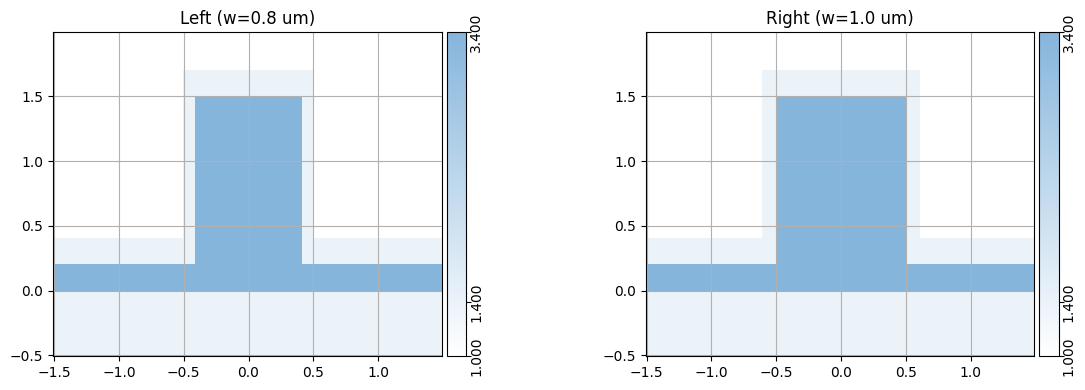

In [2]:
wl = 1.0
widths = [0.8, 1.0]
t_slab, t_soi, t_ox = 0.2, 1.5, 0.2
n_Si, n_SiO2 = 3.4, 1.4
w_sim, h_sim, y_bot = 3.0, 2.5, -0.5

si = mw.IndexMaterial(n=n_Si, name="Si", meta={"color": "orange"})
sio2 = mw.IndexMaterial(n=n_SiO2, name="SiO2", meta={"color": "steelblue"})

env = mw.Environment(wl=wl, T=25.0)
mesh = mw.Mesh2D(
    x=np.linspace(-w_sim / 2, w_sim / 2, 101),
    y=np.linspace(y_bot, y_bot + h_sim, 101),
    # num_pml=(10, 10),
)


def make_cross_section(w):
    structures = [
        mw.Structure2D(
            material=sio2,
            geometry=mw.Rectangle(
                x_min=-w_sim / 2,
                x_max=w_sim / 2,
                y_min=y_bot,
                y_max=t_slab + t_ox,
            ),
            mesh_order=2,
        ),
        mw.Structure2D(
            material=sio2,
            geometry=mw.Rectangle(
                x_min=-w / 2 - t_ox / 2,
                x_max=w / 2 + t_ox / 2,
                y_min=t_slab + t_ox,
                y_max=t_soi + t_ox,
            ),
            mesh_order=2,
        ),
        mw.Structure2D(
            material=si,
            geometry=mw.Rectangle(
                x_min=-w_sim / 2,
                x_max=w_sim / 2,
                y_min=0.0,
                y_max=t_slab,
            ),
            mesh_order=1,
        ),
        mw.Structure2D(
            material=si,
            geometry=mw.Rectangle(
                x_min=-w / 2,
                x_max=w / 2,
                y_min=t_slab,
                y_max=t_soi,
            ),
            mesh_order=1,
        ),
    ]
    return mw.CrossSection(structures=structures, mesh=mesh, env=env)


cs_left = make_cross_section(widths[0])
cs_right = make_cross_section(widths[1])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
cs_left._visualize(ax=axes[0], show=False)
axes[0].set_title(f"Left (w={widths[0]} um)")
cs_right._visualize(ax=axes[1], show=False)
axes[1].set_title(f"Right (w={widths[1]} um)")
plt.tight_layout()
plt.show()

### 6.2 Compute, filter, and orthonormalize modes

**Critical choices**: `symmetric=False, conjugate=True` — the conjugated asymmetric Poynting product.

Before orthonormalization, we filter out ill-conditioned modes using three criteria:
1. **Forward power**: $P_i = \text{Re}\langle i, i \rangle_{\text{conj}} > P_{\min}$
2. **Low PML participation**: fraction of energy density in PML region $< f_{\max}$
3. **Moderate attenuation**: $|\text{Im}(n_{\text{eff},i})| < \alpha_{\max}$

During orthonormalization, modes that don't meaningfully contribute a new basis vector
(residual norm below threshold) are also discarded.

In [3]:
# The conjugated asymmetric Poynting inner product: ½∫(E₁*×H₂)·ẑ dA
# This is the power inner product: ip(a,a) = P_a (time-averaged power).
ip = partial(mw.inner_product, symmetric=False, conjugate=True)

num_modes = 100

modes_left_raw = mw.compute_modes(cs_left, num_modes=num_modes, inner_product=ip)
modes_right_raw = mw.compute_modes(cs_right, num_modes=num_modes, inner_product=ip)
print(f"Raw modes: {len(modes_left_raw)} left, {len(modes_right_raw)} right")


# --- Mode filtering ---
def pml_fraction(mode):
    """Fraction of energy density in the PML region."""
    numx, numy = mode.mesh.num_pml
    ed = np.real(energy_density(mode))
    m, n = ed.shape
    lft = ed[:numx, :]
    rgt = ed[m - numx :, :]
    top = ed[numx : m - numx, :numy]
    btm = ed[numx : m - numx, n - numy :]
    rest = ed[numx : m - numx, numy : n - numy]
    pml_sum = lft.sum() + rgt.sum() + top.sum() + btm.sum()
    total = pml_sum + rest.sum()
    return float(pml_sum / total) if total > 0 else 1.0


def filter_modes(modes, ip, P_min=1e-2, f_pml_max=0.1, alpha_max=1.0):
    """Filter modes by forward power, PML participation, and attenuation."""
    kept = []
    reasons = {"power": 0, "pml": 0, "attn": 0}
    for m in modes:
        # ip is already the conjugated product, so Re(ip(m,m)) = forward power
        P = np.real(ip(m, m))
        if P < P_min:
            reasons["power"] += 1
            continue
        f_pml = pml_fraction(m)
        if f_pml > f_pml_max:
            reasons["pml"] += 1
            continue
        if abs(np.imag(m.neff)) > alpha_max:
            reasons["attn"] += 1
            continue
        kept.append(m)
    print(
        f"  Kept {len(kept)}/{len(modes)} — rejected: "
        f"{reasons['power']} (low power), {reasons['pml']} (PML), "
        f"{reasons['attn']} (high attn)"
    )
    return kept


print("Filtering left modes:")
modes_left_filt = filter_modes(modes_left_raw, ip)
print("Filtering right modes:")
modes_right_filt = filter_modes(modes_right_raw, ip)


# --- Orthonormalization with meaningful-contribution threshold ---
def orthonormalize_strict(modes, ip, tol=1e-2):
    """Gram-Schmidt orthonormalization, dropping modes with residual norm < tol."""
    if not modes:
        return []
    basis = []
    n_dropped = 0
    for mode in modes:
        current = mode
        for b in basis:
            coeff = ip(b, current) / ip(b, b)
            current = current - coeff * b
        norm_sq = ip(current, current)
        if np.abs(norm_sq) < tol:
            n_dropped += 1
            continue
        basis.append(current / np.sqrt(norm_sq))
    print(
        f"  Orthonormalized: {len(basis)} kept, {n_dropped} dropped (residual < {tol})"
    )
    return basis


print("Orthonormalizing left modes:")
modes_left = orthonormalize_strict(modes_left_filt, ip)
print("Orthonormalizing right modes:")
modes_right = orthonormalize_strict(modes_right_filt, ip)

Raw modes: 100 left, 100 right
Filtering left modes:
  Kept 100/100 — rejected: 0 (low power), 0 (PML), 0 (high attn)
Filtering right modes:
  Kept 100/100 — rejected: 0 (low power), 0 (PML), 0 (high attn)
Orthonormalizing left modes:
  Orthonormalized: 100 kept, 0 dropped (residual < 0.01)
Orthonormalizing right modes:
  Orthonormalized: 100 kept, 0 dropped (residual < 0.01)


Left cross-section modes


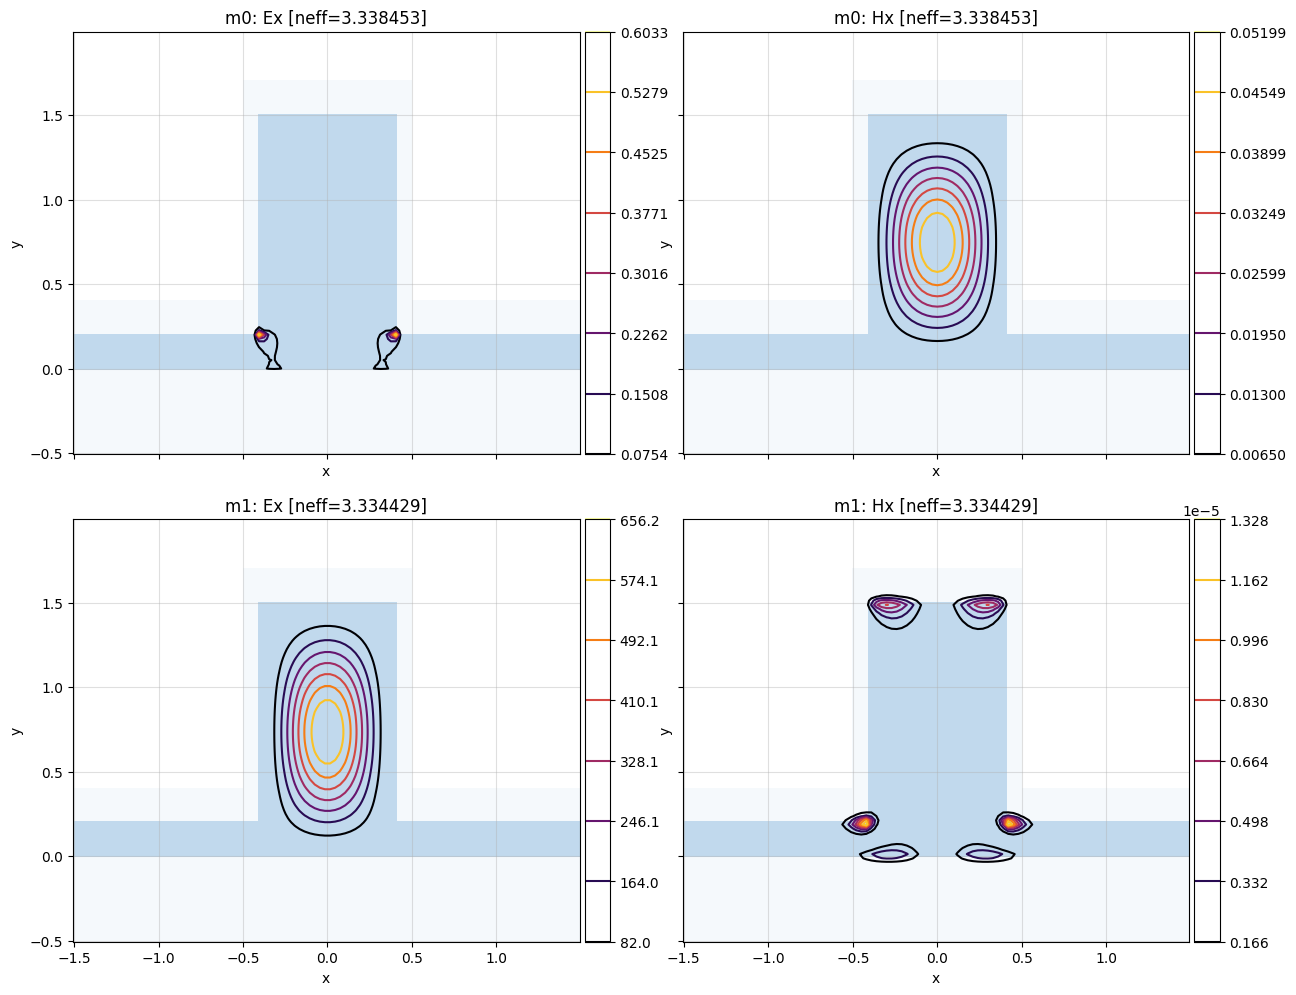

Right cross-section modes


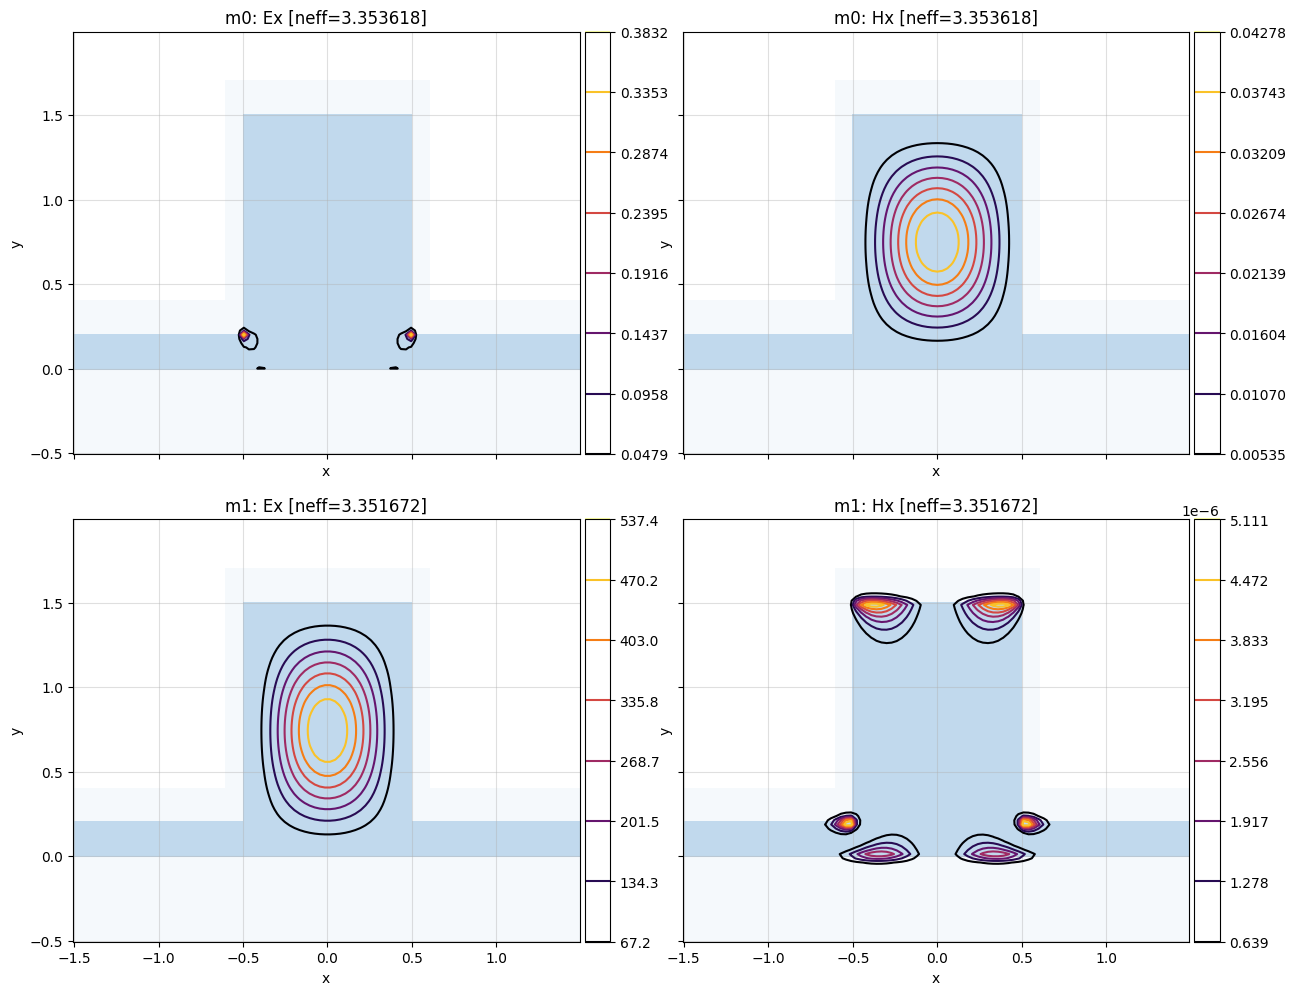

In [4]:
# Visualize left and right mode sets
print("Left cross-section modes")
mw.visualize(modes_left[:2], fields=("Ex", "Hx"))

print("Right cross-section modes")
mw.visualize(modes_right[:2], fields=("Ex", "Hx"))

In [5]:
# Verify orthonormality: G_LL and G_RR should be ≈ I
def overlap_matrix(modes_a, modes_b, op):
    M = np.zeros((len(modes_a), len(modes_b)), dtype=np.complex128)
    for i, ma in enumerate(modes_a):
        for j, mb in enumerate(modes_b):
            M[i, j] = op(ma, mb)
    return M


N = min(len(modes_left), len(modes_right))
mL = modes_left[:N]
mR = modes_right[:N]

G_LL = overlap_matrix(mL, mL, ip)
G_RR = overlap_matrix(mR, mR, ip)
I = np.eye(N)

print(f"N = {N}")
print(f"||G_LL - I||_F = {np.linalg.norm(G_LL - I):.3e}")
print(f"||G_RR - I||_F = {np.linalg.norm(G_RR - I):.3e}")
# Verify Hermitian property (conjugated case: G = G†, not just G = G^T)
print(
    f"||G_LL - G_LL†||_F = {np.linalg.norm(G_LL - G_LL.conj().T):.3e}  (should be ≈ 0)"
)
print(
    f"||G_RR - G_RR†||_F = {np.linalg.norm(G_RR - G_RR.conj().T):.3e}  (should be ≈ 0)"
)

# Diagnostic: how complex are the modes?
# PML introduces complex neff and complex field profiles. This determines whether
# conjugated and unconjugated products give different results.
neffs_L = np.array([m.neff for m in mL])
neffs_R = np.array([m.neff for m in mR])

print(f"\nMode complexity diagnostic:")
print(
    f"  Left modes:  max|Im(neff)| = {np.max(np.abs(np.imag(neffs_L))):.3e},  "
    f"mean|Im(neff)| = {np.mean(np.abs(np.imag(neffs_L))):.3e}"
)
print(
    f"  Right modes: max|Im(neff)| = {np.max(np.abs(np.imag(neffs_R))):.3e},  "
    f"mean|Im(neff)| = {np.mean(np.abs(np.imag(neffs_R))):.3e}"
)


# Field complexity: ||Im(E)|| / ||E|| for each mode
def field_complexity(modes):
    ratios = []
    for m in modes:
        E = np.stack([m.Ex, m.Ey])
        ratios.append(np.linalg.norm(np.imag(E)) / max(np.linalg.norm(E), 1e-30))
    return np.array(ratios)


fc_L = field_complexity(mL)
fc_R = field_complexity(mR)
print(
    f"  Left fields:  max||Im(E)||/||E|| = {fc_L.max():.3e},  "
    f"mean = {fc_L.mean():.3e},  guided (mode 0) = {fc_L[0]:.3e}"
)
print(
    f"  Right fields: max||Im(E)||/||E|| = {fc_R.max():.3e},  "
    f"mean = {fc_R.mean():.3e},  guided (mode 0) = {fc_R[0]:.3e}"
)

if fc_L.max() > 0.01 or fc_R.max() > 0.01:
    print(
        "  ⚠ Modes have significant imaginary parts (likely PML modes) — "
        "conjugated ≠ unconjugated for these modes."
    )
else:
    print("  ✓ Modes are effectively real — conjugated ≈ unconjugated.")

N = 100
||G_LL - I||_F = 6.568e-02
||G_RR - I||_F = 3.965e-02
||G_LL - G_LL†||_F = 9.288e-02  (should be ≈ 0)
||G_RR - G_RR†||_F = 5.607e-02  (should be ≈ 0)

Mode complexity diagnostic:
  Left modes:  max|Im(neff)| = 0.000e+00,  mean|Im(neff)| = 0.000e+00
  Right modes: max|Im(neff)| = 0.000e+00,  mean|Im(neff)| = 0.000e+00
  Left fields:  max||Im(E)||/||E|| = 1.225e-16,  mean = 5.266e-17,  guided (mode 0) = 1.225e-16
  Right fields: max||Im(E)||/||E|| = 1.225e-16,  mean = 6.858e-17,  guided (mode 0) = 0.000e+00
  ✓ Modes are effectively real — conjugated ≈ unconjugated.


### 6.3 Build overlap matrices and compute the interface S-matrix

In [6]:
# Cross-overlap matrices (conjugated asymmetric product → O_LR ≠ O_RL† in general)
O_LR = overlap_matrix(mL, mR, ip)
O_RL = overlap_matrix(mR, mL, ip)

print(
    f"||O_LR - O_RL†||_F = {np.linalg.norm(O_LR - O_RL.conj().T):.6f}  (should be nonzero!)"
)
print(f"||O_LR||_F = {np.linalg.norm(O_LR):.6f}")

# Interface matrices (orthonormal modes → G = I)
# Key difference from unconjugated: O_RL^T → O_RL† (conjugate transpose)
# Use np.linalg.solve(A, B) instead of inv(A) @ B for numerical stability.
A_LR = O_LR + O_RL.conj().T
T_LR = np.linalg.solve(A_LR.T, 2.0 * np.eye(N)).T
R_LL = 0.5 * (O_RL.conj().T - O_LR) @ T_LR

A_RL = O_RL + O_LR.conj().T
T_RL = np.linalg.solve(A_RL.T, 2.0 * np.eye(N)).T
R_RR = 0.5 * (O_LR.conj().T - O_RL) @ T_RL

# Full S-matrix: [a⁻; b⁺] = S [a⁺; b⁻]
S = np.block(
    [
        [R_LL, T_RL],
        [T_LR, R_RR],
    ]
)

print(f"\nInterface S-matrix shape: {S.shape}")
print(f"cond(O_LR + O_RL†) = {np.linalg.cond(A_LR):.3e}")
print(f"|T_LR[0,0]| = {abs(T_LR[0, 0]):.6f}")
print(f"|R_LL[0,0]| = {abs(R_LL[0, 0]):.6f}")
print(f"|T_RL[0,0]| = {abs(T_RL[0, 0]):.6f}")
print(f"|R_RR[0,0]| = {abs(R_RR[0, 0]):.6f}")

||O_LR - O_RL†||_F = 0.913739  (should be nonzero!)
||O_LR||_F = 9.531532

Interface S-matrix shape: (200, 200)
cond(O_LR + O_RL†) = 2.629e+05
|T_LR[0,0]| = 0.986014
|R_LL[0,0]| = 0.000823
|T_RL[0,0]| = 0.986014
|R_RR[0,0]| = 0.006071


### 6.4 Sanity checks

In [7]:
# Same-medium check: L→L should give T=I, R=0
O_ll = overlap_matrix(mL, mL, ip)
A_ll = O_ll + O_ll.conj().T
T_ll = np.linalg.solve(A_ll.T, 2.0 * np.eye(N)).T
R_ll_self = 0.5 * (O_ll.conj().T - O_ll) @ T_ll

print("Same-medium sanity check (L→L):")
print(f"  ||T_LL - I||_F = {np.linalg.norm(T_ll - I):.3e}")
print(f"  ||R_LL||_F     = {np.linalg.norm(R_ll_self):.3e}")

# Passivity check: singular values of S should be ≤ 1 for a lossless interface.
# With the conjugated inner product, σ(S) ≤ 1 directly measures power conservation
# (no caveat about real modes needed for the interpretation). However, passivity
# can still be violated numerically due to truncation or ill-conditioned PML modes.
svals = np.linalg.svd(S, compute_uv=False)
print(f"\nPassivity (σ(S) ≤ 1 — power criterion, conjugated product):")
print(f"  max σ(S)  = {svals.max():.6f}")
print(f"  min σ(S)  = {svals.min():.6f}")
if svals.max() > 1.0:
    print(f"  ⚠ σ_max > 1 — truncation/PML effect")

# Reciprocity check.
# In the unconjugated case, T_LR^T = T_RL is an algebraic identity: the two
# overlap systems (O_LR + O_RL^T) and (O_RL + O_LR^T) are transposes of each
# other, so T_LR^T = T_RL by construction.
# In the conjugated case, we have (O_LR + O_RL†) and (O_RL + O_LR†).
# T_LR^T = T_RL requires (O_LR + O_RL†)^T = O_RL + O_LR†, i.e.,
# O_LR^T + O_RL^* = O_RL + O_LR^{*T}.
# For real overlaps (O = O*), this is trivially true.
# For complex overlaps (PML modes), it does NOT hold in general.
print(
    f"\nReciprocity (transmission): ||T_LR^T - T_RL||_F = {np.linalg.norm(T_LR.T - T_RL):.3e}"
)
print(
    f"Reciprocity (R_LL sym):     ||R_LL - R_LL^T||_F = {np.linalg.norm(R_LL - R_LL.T):.3e}"
)
print(
    f"Reciprocity (R_RR sym):     ||R_RR - R_RR^T||_F = {np.linalg.norm(R_RR - R_RR.T):.3e}"
)
print(
    f"Full S:                     ||S - S^T||_F       = {np.linalg.norm(S - S.T):.3e}"
)

Same-medium sanity check (L→L):
  ||T_LL - I||_F = 4.616e-02
  ||R_LL||_F     = 4.636e-02

Passivity (σ(S) ≤ 1 — power criterion, conjugated product):
  max σ(S)  = 261172.601259
  min σ(S)  = 0.985520
  ⚠ σ_max > 1 — truncation/PML effect

Reciprocity (transmission): ||T_LR^T - T_RL||_F = 1.760e-09
Reciprocity (R_LL sym):     ||R_LL - R_LL^T||_F = 4.711e+04
Reciprocity (R_RR sym):     ||R_RR - R_RR^T||_F = 3.899e+03
Full S:                     ||S - S^T||_F       = 4.727e+04


### 6.5 Passivity enforcement (SVD clipping)

With a truncated modal basis, the S-matrix can violate passivity ($\sigma_{\max} > 1$).
This is because the boundary matching over-estimates transmission when the basis is incomplete —
the "missing" radiation modes that would carry away scattered power are not accounted for.

A standard post-processing fix: clip the singular values of $S$ to $\leq 1$.

In [8]:
# SVD passivity correction: clip singular values to ≤ 1
U, sigma, Vh = np.linalg.svd(S, full_matrices=False)
sigma_clip = np.minimum(sigma, 1.0)
S_passive = (U * sigma_clip) @ Vh

# Extract blocks from the passive S-matrix
R_LL_p = S_passive[:N, :N]
T_RL_p = S_passive[:N, N:]
T_LR_p = S_passive[N:, :N]
R_RR_p = S_passive[N:, N:]

svals_p = np.linalg.svd(S_passive, compute_uv=False)
print("After passivity correction:")
print(f"  max σ(S)  = {svals_p.max():.6f}")
print(f"  |T_LR[0,0]| = {abs(T_LR_p[0, 0]):.6f}  (raw: {abs(T_LR[0, 0]):.6f})")
print(f"  |R_LL[0,0]| = {abs(R_LL_p[0, 0]):.6f}  (raw: {abs(R_LL[0, 0]):.6f})")
print(f"  ||S - S_passive||_F = {np.linalg.norm(S - S_passive):.3e}")

After passivity correction:
  max σ(S)  = 1.000000
  |T_LR[0,0]| = 0.985056  (raw: 0.986014)
  |R_LL[0,0]| = 0.000766  (raw: 0.000823)
  ||S - S_passive||_F = 3.679e+05


### 6.6 Comparison with reference

In [9]:
S_ref = np.load("assets/s_ref.npy")
N_ref = S_ref.shape[0] // 2
print(f"Reference S-matrix: {S_ref.shape} ({N_ref} modes per port)")

# Extract first N_ref modes from both raw and passive S-matrices
idx = np.r_[np.arange(N_ref), N + np.arange(N_ref)]
S_sub = S[np.ix_(idx, idx)]
S_sub_p = S_passive[np.ix_(idx, idx)]

print(f"\n{'':>20} {'Raw':>12} {'Passive':>12} {'Reference':>12}")
print(f"{'':>20} {'----------':>12} {'----------':>12} {'----------':>12}")
for label, i, j in [
    ("|T_LR[0,0]|", N_ref, 0),
    ("|T_LR[1,1]|", N_ref + 1, 1),
    ("|R_LL[0,0]|", 0, 0),
    ("|R_RR[0,0]|", N_ref, N_ref),
    ("|T_RL[0,0]|", 0, N_ref),
    ("|R_LL[1,1]|", 1, 1),
    ("|R_RR[1,1]|", N_ref + 1, N_ref + 1),
]:
    raw = abs(S_sub[i, j])
    pas = abs(S_sub_p[i, j])
    ref = abs(S_ref[i, j])
    print(f"{label:>20} {raw:12.6f} {pas:12.6f} {ref:12.6f}")

err_raw = np.linalg.norm(np.abs(S_sub) - np.abs(S_ref))
err_pas = np.linalg.norm(np.abs(S_sub_p) - np.abs(S_ref))
print(f"\n||abs(S_raw) - abs(S_ref)||_F = {err_raw:.3e}")
print(f"||abs(S_pas) - abs(S_ref)||_F = {err_pas:.3e}")

Reference S-matrix: (4, 4) (2 modes per port)

                              Raw      Passive    Reference
                       ----------   ----------   ----------
         |T_LR[0,0]|     0.986014     0.985056     0.988224
         |T_LR[1,1]|     0.983658     0.983460     0.986166
         |R_LL[0,0]|     0.000823     0.000766     0.004533
         |R_RR[0,0]|     0.006071     0.005489     0.004533
         |T_RL[0,0]|     0.986014     0.985010     0.988224
         |R_LL[1,1]|     0.000147     0.000147     0.000453
         |R_RR[1,1]|     0.002348     0.002051     0.000453

||abs(S_raw) - abs(S_ref)||_F = 1.990e-01
||abs(S_pas) - abs(S_ref)||_F = 7.275e-03


In [10]:
# Side-by-side |S| matrices
print("abs(S_raw) [this work]:")
print(np.array2string(np.abs(S_sub), precision=6, suppress_small=True))
print()
print("abs(S_passive) [this work]:")
print(np.array2string(np.abs(S_sub_p), precision=6, suppress_small=True))
print("\nabs(S_ref):")
print(np.array2string(np.abs(S_ref), precision=6, suppress_small=True))

abs(S_raw) [this work]:
[[0.000823 0.       0.986014 0.096195]
 [0.002732 0.000147 0.       0.983658]
 [0.986014 0.       0.006071 0.145121]
 [0.096195 0.983658 0.       0.002348]]

abs(S_passive) [this work]:
[[0.000766 0.       0.98501  0.      ]
 [0.       0.000147 0.       0.983431]
 [0.985056 0.       0.005489 0.000001]
 [0.       0.98346  0.       0.002051]]

abs(S_ref):
[[0.004533 0.       0.988224 0.      ]
 [0.       0.000453 0.       0.986166]
 [0.988224 0.       0.004533 0.      ]
 [0.       0.986166 0.       0.000453]]


### 6.7 Convergence with number of modes

The interface S-matrix is a truncated modal expansion. The quality improves as more modes are included (better completeness). Let's check how the key entries converge.

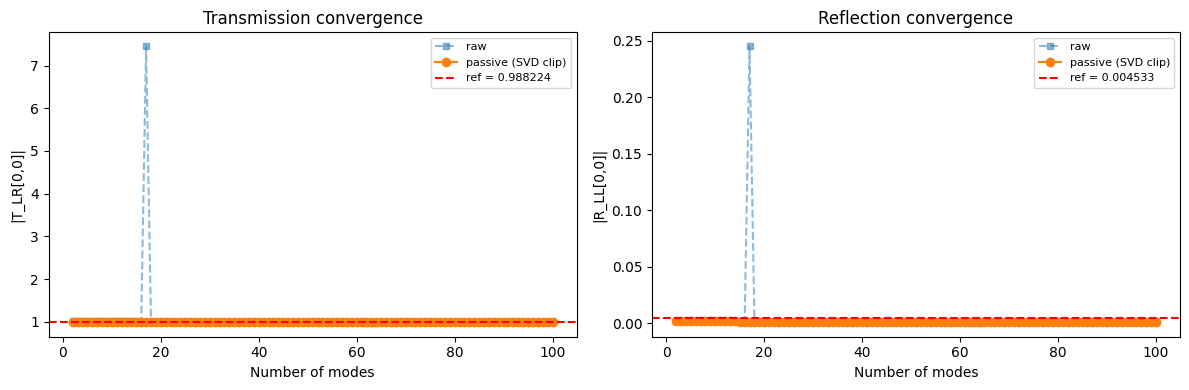

In [11]:
# Convergence: compute S-matrix using first K modes for K = 2, 3, ..., N
results = []
for K in range(2, N + 1):
    mL_k = modes_left[:K]
    mR_k = modes_right[:K]
    O_lr_k = overlap_matrix(mL_k, mR_k, ip)
    O_rl_k = overlap_matrix(mR_k, mL_k, ip)

    # Compute all 4 blocks (conjugate transpose: .conj().T)
    A_lr_k = O_lr_k + O_rl_k.conj().T
    T_lr_k = np.linalg.solve(A_lr_k.T, 2.0 * np.eye(K)).T
    R_ll_k = 0.5 * (O_rl_k.conj().T - O_lr_k) @ T_lr_k

    A_rl_k = O_rl_k + O_lr_k.conj().T
    T_rl_k = np.linalg.solve(A_rl_k.T, 2.0 * np.eye(K)).T
    R_rr_k = 0.5 * (O_lr_k.conj().T - O_rl_k) @ T_rl_k

    # Full S-matrix, then SVD passivity clipping
    S_k = np.block(
        [
            [R_ll_k, T_rl_k],
            [T_lr_k, R_rr_k],
        ]
    )
    U_k, s_k, Vh_k = np.linalg.svd(S_k, full_matrices=False)
    S_k_p = (U_k * np.minimum(s_k, 1.0)) @ Vh_k
    T_lr_p_k = S_k_p[K:, :K]
    R_ll_p_k = S_k_p[:K, :K]
    results.append(
        (
            K,
            abs(T_lr_k[0, 0]),
            abs(R_ll_k[0, 0]),
            abs(T_lr_p_k[0, 0]),
            abs(R_ll_p_k[0, 0]),
        )
    )

Ks, Ts, Rs, Ts_p, Rs_p = zip(*results)
ref_T = abs(S_ref[N_ref, 0])
ref_R = abs(S_ref[0, 0])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(Ks, Ts, "s--", alpha=0.5, label="raw", markersize=4)
ax1.plot(Ks, Ts_p, "o-", label="passive (SVD clip)")
ax1.axhline(ref_T, color="r", ls="--", label=f"ref = {ref_T:.6f}")
ax1.set_xlabel("Number of modes")
ax1.set_ylabel("|T_LR[0,0]|")
ax1.legend(fontsize=8)
ax1.set_title("Transmission convergence")

ax2.plot(Ks, Rs, "s--", alpha=0.5, label="raw", markersize=4)
ax2.plot(Ks, Rs_p, "o-", label="passive (SVD clip)")
ax2.axhline(ref_R, color="r", ls="--", label=f"ref = {ref_R:.6f}")
ax2.set_xlabel("Number of modes")
ax2.set_ylabel("|R_LL[0,0]|")
ax2.legend(fontsize=8)
ax2.set_title("Reflection convergence")

plt.tight_layout()
plt.show()

---
## 7. Discussion

### Conjugated vs. unconjugated formulas

| Aspect | Unconjugated (`conjugate=False`) | Conjugated (`conjugate=True`) |
|--------|----------------------------------|-------------------------------|
| Inner product | $\frac{1}{2}\int(\mathbf{e}_a \times \mathbf{h}_b)\cdot\hat{z}\,dA$ | $\frac{1}{2}\int(\mathbf{e}_a^* \times \mathbf{h}_b)\cdot\hat{z}\,dA$ |
| Metric symmetry | $G = G^T$ (real symmetric) | $G = G^\dagger$ (Hermitian) |
| Transmission | $T_{LR} = 2(O_{LR} + O_{RL}^T)^{-1}$ | $T_{LR} = 2(O_{LR} + O_{RL}^\dagger)^{-1}$ |
| Reflection | $R_{LL} = \frac{1}{2}(O_{RL}^T - O_{LR})T_{LR}$ | $R_{LL} = \frac{1}{2}(O_{RL}^\dagger - O_{LR})T_{LR}$ |
| $\sigma(S) \leq 1$ meaning | Power conservation only if modes are real | Power conservation (always valid interpretation) |
| $T_{LR}^T = T_{RL}$ | Algebraic identity (by construction) | Only for real overlaps |

Note on the reciprocity row: in the unconjugated case, $T_{LR}^T = T_{RL}$ is a **structural
consequence** of the algebra — $(O_{LR} + O_{RL}^T)^T = O_{RL} + O_{LR}^T$ is always true,
so the two transmission matrices are transposes of each other by construction. This is not a
test of physical reciprocity; it holds for any pair of matrices. In the conjugated case, the
analogous relation requires $(O_{LR} + O_{RL}^\dagger)^T = O_{RL} + O_{LR}^\dagger$, which
only holds when the overlaps are real-valued.

### When does it matter?

The underlying geometry has real refractive indices ($n_{\text{Si}} = 3.4$, $n_{\text{SiO}_2} = 1.4$),
so guided modes have real $\beta$ and real field profiles. For these modes, $\mathbf{e}^* = \mathbf{e}$
and the conjugated product reduces to the unconjugated one.

However, this notebook uses **PML** (`num_pml=(10,10)`), which introduces complex-valued
$\varepsilon$ in the absorbing layers. PML-captured radiation modes generally have complex $\beta$
and complex field profiles, making the conjugated and unconjugated products genuinely different
for those modes. The mode complexity diagnostic above quantifies this effect.

The distinction becomes important for:
- **PML modes** with complex $\beta$ and complex field profiles (as in this notebook)
- **Lossy or gain media** (complex $\varepsilon$) where all mode profiles are genuinely complex
- **Leaky modes** in open waveguides

In these cases, the conjugated formulation gives the physically correct power-conservation
interpretation for $\sigma(S)$, while the unconjugated formulation preserves the algebraic
$T_{LR}^T = T_{RL}$ identity. The choice depends on which property is more important for
the application.

### On the metric

With orthonormalized modes, $G_{LL} = G_{RR} = I$ and the metric factors vanish.
The simple formulas work directly. The generalized formulas
$T = 2(O + O^\dagger)^{-1} G$ are needed only when modes are not orthonormalized.

### Passivity and the truncation effect

With a **complete** basis of power-orthonormal modes, the interface formulas yield a unitary
S-matrix ($S^\dagger S = I$). With a **truncated** basis, or with ill-conditioned PML modes,
the S-matrix can violate passivity ($\sigma_{\max} > 1$). The conjugated product ensures that
$\sigma(S) \leq 1$ is the correct power-conservation test, but does not guarantee it is satisfied —
that depends on the numerical quality of the modal basis.

**Why does truncation cause $|T| > 1$?** Consider the scalar (single-mode) case. With complete
bases, the overlap integrals satisfy $o_{LR} + o_{RL}^* = 2$ (completeness), giving
$T = 2/(o_{LR} + o_{RL}^*) = 1$. With truncated bases, both
overlaps are reduced (the missing modes are absent),
so $|o_{LR} + o_{RL}^*| < 2$ and $|T| > 1$.

For the multi-mode case, the same mechanism operates on each singular component of the overlap
matrices. This is an empirical observation — not a rigorous matrix bound — but it explains the
systematic $|T| > 1$ behavior seen in practice.

The standard fix is **SVD passivity enforcement**: clip singular values to $\leq 1$.

### Discrepancies with the reference

Remaining differences between this computation and `s_ref.npy` arise from modal completeness,
mesh resolution, PML mode conditioning, and solver numerics. For the guided modes (which are
effectively real), the conjugated and unconjugated formulations give nearly identical results.
For PML-captured radiation modes (which are complex), the two formulations differ, which may
affect the convergence behavior as more modes are included.